Data Preprocessing

In [1]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
BASE = Path('..').resolve()
RAW = BASE / 'data' / 'raw' / 'behavioral_api_dataset_v2.csv'
PROC = BASE / 'data' / 'processed'
REPORTS = BASE / 'reports'
FIGS = REPORTS / 'figures'
for p in [PROC, REPORTS, FIGS]:
    p.mkdir(parents=True, exist_ok=True)

FEATURES = [
    'inter_api_access_duration(sec)', 'api_access_uniqueness', 'sequence_length(count)',
    'vsession_duration(min)', 'ip_type', 'num_sessions', 'num_users',
    'num_unique_apis', 'source', 'failed_auth_count', 'token_reuse_ratio',
    'status_4xx_ratio', 'status_5xx_ratio'
]
TARGET = 'attack_class'


In [3]:
df = pd.read_csv(RAW)
print('Raw shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))


Raw shape: (6000, 15)
Missing values: 0


In [4]:
# Keep only required columns and drop duplicates
keep = FEATURES + [TARGET]
df = df[keep].drop_duplicates().reset_index(drop=True)
print('After drop_duplicates:', df.shape)

After drop_duplicates: (6000, 14)


In [5]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.to_csv(PROC / 'X_train.csv', index=False)
X_test.to_csv(PROC / 'X_test.csv', index=False)
y_train.to_frame(name=TARGET).to_csv(PROC / 'y_train.csv', index=False)
y_test.to_frame(name=TARGET).to_csv(PROC / 'y_test.csv', index=False)

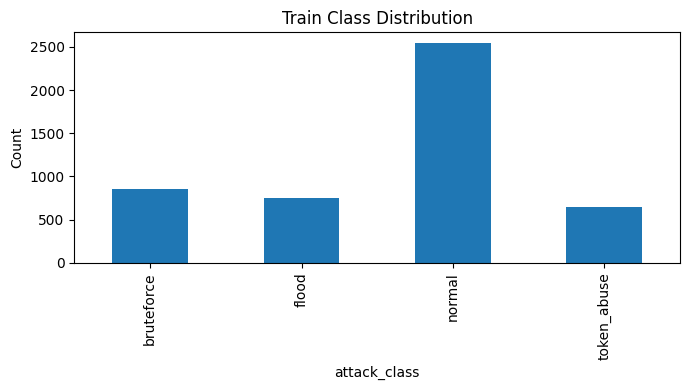

Saved processed files in data/processed


In [7]:
summary = pd.DataFrame([
    {'split': 'train', 'rows': len(X_train)},
    {'split': 'test', 'rows': len(X_test)}
])
summary.to_csv(REPORTS / '01_preprocessing_split_summary.csv', index=False)

vc = y_train.value_counts().sort_index()
plt.figure(figsize=(7,4))
vc.plot(kind='bar')
plt.title('Train Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGS / '01_train_class_distribution.png', dpi=160)
plt.show()

print('Saved processed files in data/processed')
